<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             50 non-null     int64 
 1   area              50 non-null     int64 
 2   bedrooms          50 non-null     int64 
 3   bathrooms         50 non-null     int64 
 4   stories           50 non-null     int64 
 5   mainroad          50 non-null     object
 6   guestroom         50 non-null     object
 7   basement          50 non-null     object
 8   hotwaterheating   50 non-null     object
 9   airconditioning   50 non-null     object
 10  parking           50 non-null     int64 
 11  prefarea          50 non-null     object
 12  furnishingstatus  50 non-null     object
dtypes: int64(6), object(7)
memory usage: 5.2+ KB


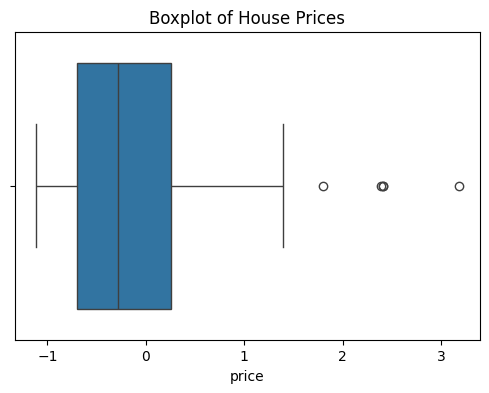

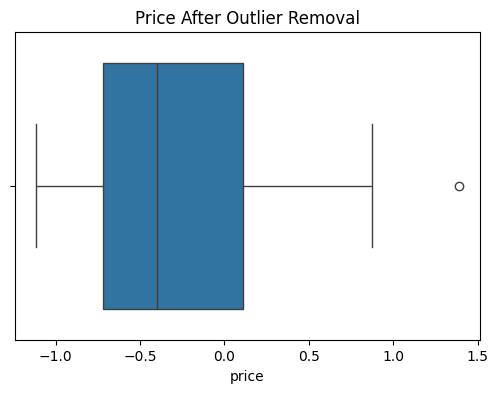

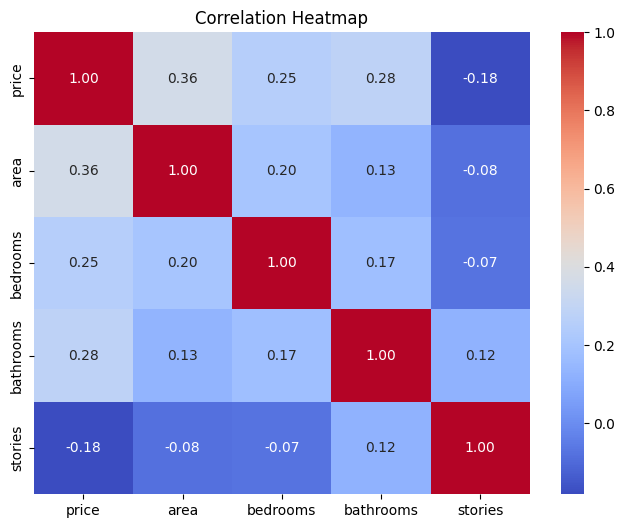

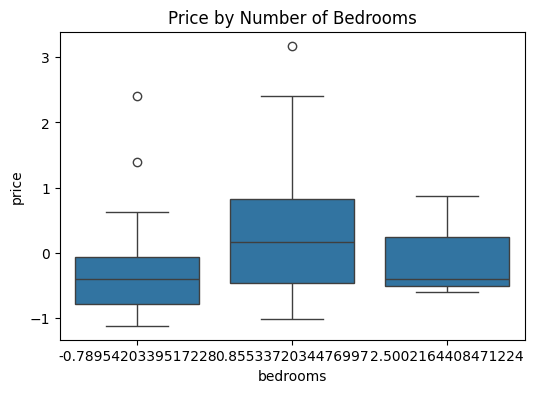

In [4]:
import pandas as pd
import numpy as np

data = pd.read_csv("/content/house-price.csv")
data =data.head(50)
data.info()
data.isnull().sum()
from sklearn.preprocessing import LabelEncoder, StandardScaler
#price	area	bedrooms	bathrooms	stories	mainroad	guestroom	basement	hotwaterheating	airconditioning	parking	prefarea	furnishingstatus
data = data.head(50)
scaler = StandardScaler()
data[['price',	'area','bedrooms','bathrooms','stories']] =scaler.fit_transform(data[['price',	'area','bedrooms','bathrooms','stories']])
data[['price',	'area','bedrooms','bathrooms','stories']]

import matplotlib.pyplot as plt
import seaborn as sns



encode =LabelEncoder()
data['mainroad'] =encode.fit_transform(data['mainroad'])
data['mainroad']


plt.figure(figsize=(6,4))
sns.boxplot(x=data['price'])
plt.title('Boxplot of House Prices')
plt.show()

Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers = data[
    (data['price'] >= lower_bound) &
    (data['price'] <= upper_bound)
]
data_no_outliers


plt.figure(figsize=(6,4))
sns.boxplot(x=data_no_outliers['price'])
plt.title('Price After Outlier Removal')
plt.show()



plt.figure(figsize=(8,6))
sns.heatmap(
    data[['price',	'area','bedrooms','bathrooms','stories']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


plt.figure(figsize=(6,4))
sns.boxplot(x=data['bedrooms'], y=data['price'])
plt.title("Price by Number of Bedrooms")
plt.show()









































